In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as clr
plt.rc('text', usetex = True)

from ast import literal_eval as liteval
import numpy as np
import os

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
from file_utils import readData, copyList, readData2D, float2latex
sys.path.pop(0)

dirpath = "//media/ashwin/ASH_DRIVE_3/ashwin_md/lane/Aug_Nov2025"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Nov2025"

In [2]:
lw = 1.2
ms = 2
colors = ["blue", "green", "orange", "red", "mediumorchid", "orangered"]

0.989089 1.030764 1.01965
0.916871 0.855746 0.944655


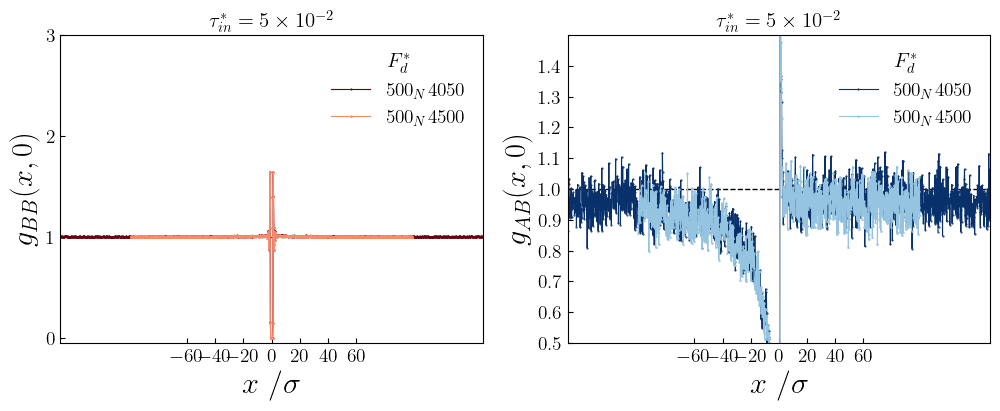

In [11]:
# Plotting gBB(x,0) and gAB(x,0) for different Pe (color scheme 1)

Fd_list = ["500_N4050", "500_N4500"]
color = ["g", "g", "#ed7d31", "r", "r", "r"]
alp = [1, 0.7, 0.6, 0.6, 0.7, 1]
MS = [".", "^", "s", "*", "o", "^", "o", "s"]

ms = 1
lw = 0.8
interval = 1

# --------- Enter the path to RDF data files ---------
file_paths = []
for i in range(len(Fd_list)):
    fpath = os.path.join(dirpath, "tau_1e-1", "Fd{fd}".format(fd = Fd_list[i]), "laneRDF_1D_asymm.dat")
    file_paths.append(fpath)

# ------------------ Choose colormaps ------------------
cmap1 = mpl.colormaps['Reds']
cmap2 = mpl.colormaps['Blues']
color_id = np.linspace(1.0, 0.4, len(file_paths))

# ------------------ Plotting begins here ------------------
fig1, ax1 = plt.subplots(1, 2, figsize = (12, 4))
# ax1_in = ax1[1].inset_axes(bounds = [0.35, 0.45, 0.4, 0.5])

for i in range(len(ax1)):
    ax1[i].axhline(y = 1, xmin = 0, xmax = 1, ls = "--", color = "k", lw = 1)
    # ax1[i].axhline(y = 0, xmin = 0, xmax = 1, ls = "--", color = "k", lw = 0.5)

for i in range(len(file_paths)):
    [rdfData, fields] = readData(file_paths[i], 2)
    
    xn = rdfData[1][0::interval]
    g_all = rdfData[2][0::interval]
    gAA = rdfData[3][0::interval]
    gAB = rdfData[4][0::interval]
    gBA = rdfData[5][0::interval]
    gBB = rdfData[6][0::interval]

    ax1[0].plot(xn, gBB, ls = "-", marker = MS[i], color = cmap1(color_id[i]), ms = ms, lw = lw, alpha = 1, 
                label = r"${fd}$".format(fd = float2latex([Fd_list[i]])))
    ax1[1].plot(xn, gAB, ls = "-", marker = MS[i], color = cmap2(color_id[i]), ms = ms, lw = lw, alpha = 1, 
                label = r"${fd}$".format(fd = float2latex([Fd_list[i]])))

    print(gAB[-1], gAB[0], gAB[2])
    # ax1_in.plot(xn, gAB, ls = "-", marker = MS[i], color = cmap2(color_id[i]), ms = ms, lw = lw, alpha = 1, 
    #             label = r"${fd}$".format(fd = float2latex([Fd_list[i]])))

ax1[0].set_ylabel(r"$g_{BB}(x, 0)$", fontsize = 22)
ax1[0].set(xlim = (-150, 150), ylim = (-0.05, 3))
ax1[0].set_xticks(np.arange(-60, 60.5, 20))
ax1[0].set_yticks(np.arange(0, 3.5, 1))
ax1[0].set_title(r"$\tau_{in}^* = 5\times 10^{-2}$", fontsize = 15, loc = "center")

ax1[1].set_ylabel(r"$g_{AB} (x, 0)$", fontsize = 22)
ax1[1].set(xlim = (-150, 150), ylim = (0.5, 1.5))
ax1[1].set_xticks(np.arange(-60, 60.5, 20))
ax1[1].set_yticks(np.arange(0.5, 1.5, 0.1))
ax1[1].set_title(r"$\tau_{in}^* = 5\times 10^{-2}$", fontsize = 15, loc = "center")

# ax1_in.set_xlabel(r"$x ~/\sigma$", fontsize = 12)
# ax1_in.set_ylabel(r"$g_{AB} (x, 0)$", fontsize = 12)
# ax1_in.set(xlim = (0.6, 1.2))
# ax1_in.set_xticks(np.arange(0.6, 1.4, 0.2))
# ax1_in.set_yticks(np.arange(0, 8, 2))

# 0.95
# ax1[1].axvline(x = 0.85, ls = "--", lw = 1, color = "k")

for i in range(len(ax1)):
    ax1[i].set_xlabel(r"$x ~/\sigma$", fontsize = 22)
    ax1[i].tick_params(axis = "both", which = "major", direction = "in", labelsize = 14)
    leg = ax1[i].legend(title = r"$F_{d}^*$", ncols = 1, frameon = False, fontsize = 14)
    leg.get_title().set_fontsize("15")

# fig1.savefig(os.path.join(figpath, "RDF_psps_tau_5e-2_Fd_500.png"), dpi = 500, bbox_inches = "tight")

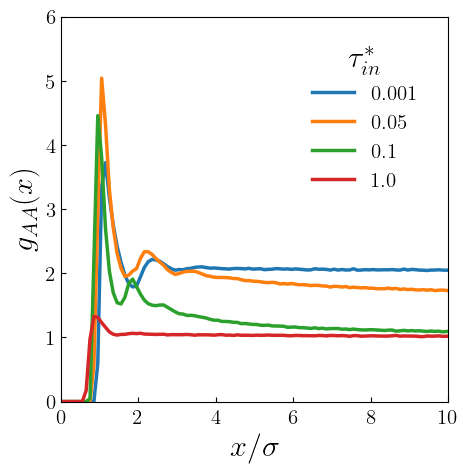

In [26]:
tau_list = ["1e-3", "5e-2", "1e-1", "1e0"]
interval = 1

fig, ax = plt.subplots(figsize = (5, 5))

fpaths = []
for i in range(len(tau_list)):
    fpath = os.path.join(dirpath, "Fd100", "tau_{Tau}".format(Tau = tau_list[i]), "laneRDF_1D_asymm.dat")
    [rdfData, fields] = readData(fpath, 2)
    
    xn = rdfData[1][0::interval]
    g_all = rdfData[2][0::interval]
    gAA = rdfData[3][0::interval]
    gAB = rdfData[4][0::interval]
    gBA = rdfData[5][0::interval]
    gBB = rdfData[6][0::interval]

    hAA = [(j - 1) for j in gAA]

    ax.plot(xn, gAA, "-", lw = 2.5, label = r"${tau}$".format(tau = liteval(tau_list[i])))

ax.set_xlabel(r"$x/\sigma$", fontsize = 22)
ax.set_ylabel(r"$g_{AA}(x)$", fontsize = 22)
ax.set(xlim = (0, 10), ylim = (0, 6))
ax.set_xticks(np.arange(0, 11, 2))
ax.set_yticks(np.arange(0, 7, 1))
ax.tick_params(axis = "x", which = "major", pad = 5, direction = "in", labelsize = 15)
ax.tick_params(axis = "x", which = "minor", direction = "in")
ax.tick_params(axis = "y", which = "major", direction = "in", labelsize = 15)
leg = ax.legend(title = r"$\tau_{in}^*$", frameon = False, ncols = 1, fontsize = 15, bbox_to_anchor = (0.6, 0.5))
leg.get_title().set_fontsize("22")

# fig.savefig(os.path.join(figpath, "RDF_Fd100.png"), dpi = 500, bbox_inches = "tight")

In [ ]:
# Plot g(x, y)

colors = ["blue", "white", "red", "orangered",  "orange", "darkorange"]
cmap = clr.LinearSegmentedColormap.from_list("bwro", colors, N = 256)

rcutx = 10
rcuty = 10
binWx = 0.05
binWy = 0.05
nRows = int(2*rcutx/binWx)
nCols = int(2*rcuty/binWy)

fig1, ax1 = plt.subplots()

fpath = os.path.join(dirpath, "Data24", "lanerdf_2D.dat")
rdf = readData2D(fpath, 5, nRows, nCols)

z = rdf[4]
zmin = 0
zmax = 5.04

levels = np.linspace(zmin, zmax, 200)

print(z.min(), z.max())
cs = ax1.contourf(np.linspace(-rcutx, rcutx, nRows), np.linspace(-rcuty, rcuty, nCols), z.transpose(), levels = levels, cmap = cmap)

cbar = fig1.colorbar(cs, ticks = np.arange(zmin, zmax+0.1, 0.5))

ax1.set_xlabel(r"$x/\sigma$", fontsize = 15)
ax1.set_ylabel(r"$y/\sigma$", fontsize = 15)
ax1.set_xticks(np.arange(-rcutx, rcutx + 1.0, 2.0))
ax1.set_yticks(np.arange(-rcuty, rcuty + 1.0, 2.0))
ax1.set_title(r"$g_{BB}(x, y)$", loc = "left", fontsize = 15)
ax1.set_title(r"$Pe = 60$", loc = "right", fontsize = 12)

# fig1.savefig(os.path.join(figpath, "rdf_nr24_BB.png"), dpi = 500, bbox_inches = "tight")